In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.552013,0.066182,0.753098,2.514226,-0.193840,0
1,1.802515,-0.328463,-1.110603,-0.264509,-2.804688,1
2,1.635665,1.997724,0.563025,-0.670619,-2.179475,0
3,1.590035,-1.369683,1.316304,0.078536,-1.329720,1
4,3.292042,-0.465647,0.691492,1.107142,0.697564,0


In [4]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [10]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [12]:
import random

# function for feature sampling
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [13]:
df1 = combined_sampling(df,0.5,0.5)
df2 = combined_sampling(df,0.5,0.5)

C:\Users\Raghav\AppData\Local\Temp\ipykernel_11916\3435463138.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']
C:\Users\Raghav\AppData\Local\Temp\ipykernel_11916\3435463138.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [14]:
df3 = combined_sampling(df,0.5,0.5)

C:\Users\Raghav\AppData\Local\Temp\ipykernel_11916\3435463138.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [15]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col2', 'target'], dtype='object')
Index(['col1', 'col4', 'target'], dtype='object')
Index(['col2', 'col4', 'target'], dtype='object')


In [16]:
df3

,col2,col4,target
51,0.765578,1.113518,0
41,-0.172711,-1.494176,1
32,-3.338076,-1.537028,1
92,1.947566,1.290810,0
61,0.264540,-0.403810,1
8,1.654970,0.299562,0
77,-1.258198,-0.982442,1
73,1.017355,0.273550,0
68,2.439854,1.007179,0
91,-1.490520,-0.394413,1


In [17]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [18]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [19]:
from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[0] <= 0.411\ngini = 0.471\nsamples = 50\nvalue = [31, 19]'),
 Text(0.4, 0.5, 'x[1] <= 0.601\ngini = 0.33\nsamples = 24\nvalue = [5, 19]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 26\nvalue = [26, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

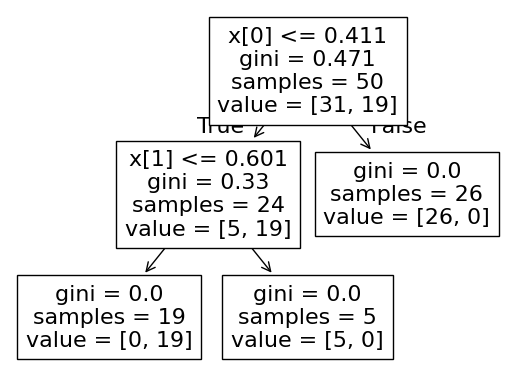

In [20]:
plot_tree(clf1)

[Text(0.6071428571428571, 0.9166666666666666, 'x[1] <= -0.032\ngini = 0.487\nsamples = 50\nvalue = [29.0, 21.0]'),
 Text(0.35714285714285715, 0.75, 'x[0] <= 2.225\ngini = 0.33\nsamples = 24\nvalue = [5, 19]'),
 Text(0.4821428571428571, 0.8333333333333333, 'True  '),
 Text(0.21428571428571427, 0.5833333333333334, 'x[0] <= 0.383\ngini = 0.18\nsamples = 20\nvalue = [2, 18]'),
 Text(0.14285714285714285, 0.4166666666666667, 'x[0] <= -0.005\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.07142857142857142, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.21428571428571427, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2857142857142857, 0.4166666666666667, 'gini = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.5, 0.5833333333333334, 'x[0] <= 2.689\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.42857142857142855, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.5714285714285714, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')

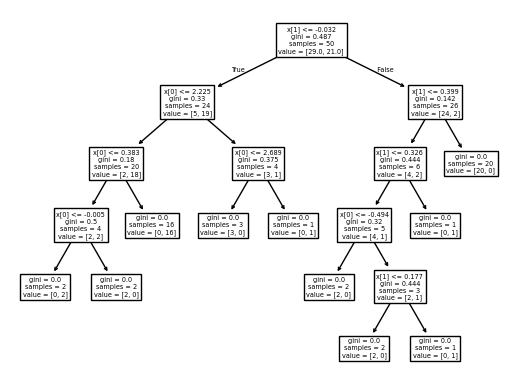

In [21]:
plot_tree(clf2)

[Text(0.5, 0.9, 'x[1] <= 0.09\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.2631578947368421, 0.7, 'x[0] <= 0.482\ngini = 0.153\nsamples = 24\nvalue = [2, 22]'),
 Text(0.381578947368421, 0.8, 'True  '),
 Text(0.15789473684210525, 0.5, 'x[0] <= -1.621\ngini = 0.087\nsamples = 22\nvalue = [1, 21]'),
 Text(0.10526315789473684, 0.3, 'x[0] <= -1.659\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.05263157894736842, 0.1, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.15789473684210525, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.21052631578947367, 0.3, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.3684210526315789, 0.5, 'x[1] <= -2.363\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.3157894736842105, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.42105263157894735, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.7368421052631579, 0.7, 'x[0] <= -0.846\ngini = 0.204\nsamples = 26\nvalue = [23, 3]'),
 Text(0.618421052631579, 0.8, '

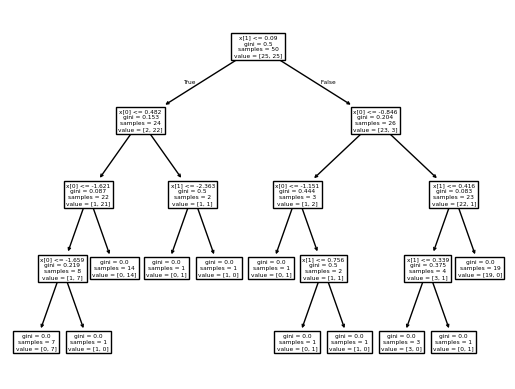

In [22]:
plot_tree(clf3)

In [23]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Raghav\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [24]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Raghav\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [25]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\Raghav\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [26]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
41,1.454448,-0.172711,-0.842392,-1.494176,-0.045224,1
81,-0.048380,1.984214,1.881304,-0.594967,-0.202789,0
97,1.444666,-1.790085,-0.058232,-1.402274,-1.018048,1
96,2.251380,1.087096,0.744093,0.560990,-1.028479,0
66,1.987090,-1.682022,-0.965444,0.079470,-2.374529,1
43,-0.387897,-0.431347,-0.055907,3.243795,-1.106040,0
61,0.948145,0.264540,-1.910190,-0.403810,-0.027519,1
27,1.415351,-1.056060,-0.065350,0.338141,-0.906087,1
4,3.292042,-0.465647,0.691492,1.107142,0.697564,0
84,-1.061836,1.476805,0.904526,1.008889,-2.058344,0
